Rows= 49
Cleaned rows= 48
                             location  price_parsed  beds_parsed  \
1  G-13, Islamabad, Islamabad Capital    79000000.0          6.0   
2  I-14, Islamabad, Islamabad Capital    30000000.0          5.0   
3  G-13, Islamabad, Islamabad Capital    75000000.0          6.0   
4  G-13, Islamabad, Islamabad Capital   155000000.0          6.0   
5  G-13, Islamabad, Islamabad Capital    79000000.0          6.0   

   baths_parsed  area_parsed  
1           6.0       2722.5  
2           5.0       1633.5  
3           6.0       2722.5  
4           6.0       5445.0  
5           6.0       2722.5  
Epoch 0: MSE = 7507250000000000.00
Epoch 100: MSE = 829881087259389.12
Epoch 200: MSE = 712916136629736.75
Epoch 300: MSE = 699576418815840.75
Epoch 400: MSE = 692028060103652.38
Epoch 500: MSE = 687115778072003.50
Epoch 600: MSE = 683903936998573.38
Epoch 700: MSE = 681803541364507.38
Epoch 800: MSE = 680429967975295.25
Epoch 900: MSE = 679531706327436.50


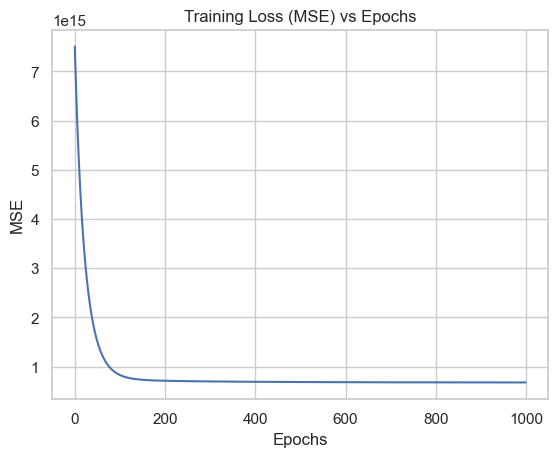

Test MSE= 819669273453584.0
Test RMSE= 28629866.80817052
R² Score= 0.5056306816885399


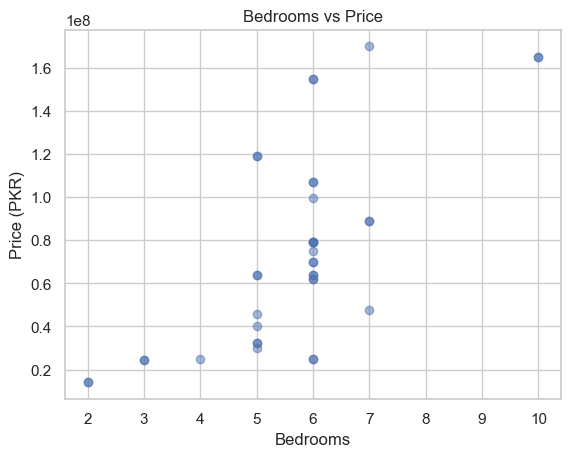

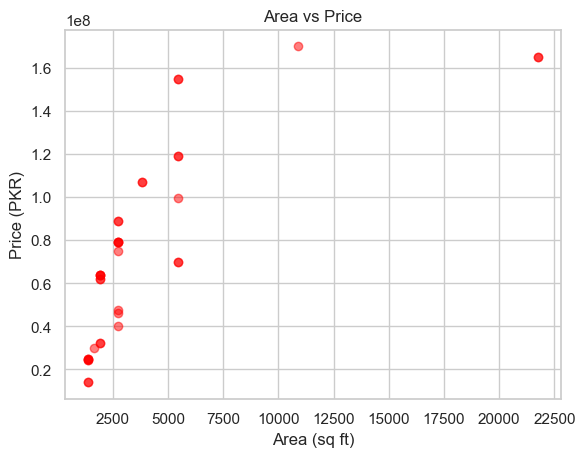


Final Equation (Linear Regression Model):
Price = 74499999.87 + (-2696682.37 * Bedrooms) + (16264456.10 * Bathrooms) + (30242945.36 * Area)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (Zameen housing data)
path = "zameen.csv" 
df = pd.read_csv(path)

print("Rows=", len(df))


# ==============================
# DATA CLEANING FUNCTIONS
# ==============================

# Convert price into numeric PKR values
# Handles formats like "2 crore", "50 lakh", or raw numbers
def parse_price(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).lower().replace(",", "").replace("rs", "").strip()

    if "crore" in x:
        num = float(x.split("crore")[0])
        return num * 1e7   # 1 crore = 10 million
    
    elif "lakh" in x:
        num = float(x.split("lakh")[0])
        return num * 1e5   # 1 lakh = 100,000
    
    else:
        digits = ''.join(ch for ch in x if ch.isdigit() or ch == '.')
        return float(digits) if digits else np.nan


# Convert area into consistent square feet format
# Handles marla, kanal, and direct sq ft values
def parse_area(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().replace(",", "")

    if "marla" in x:
        num = float(x.split("marla")[0])
        return num * 272.25   # 1 marla ≈ 272.25 sq ft

    elif "kanal" in x:
        num = float(x.split("kanal")[0])
        return num * 5445     # 1 kanal ≈ 5445 sq ft

    elif "sq" in x or "ft" in x:
        digits = ''.join(ch for ch in x if ch.isdigit() or ch == '.')
        return float(digits)

    else:
        digits = ''.join(ch for ch in x if ch.isdigit() or ch == '.')
        return float(digits) if digits else np.nan


# Extract numeric values from text columns (e.g., "3 beds" → 3)
def extract_number(x):
    if pd.isna(x):
        return np.nan

    x = str(x)
    digits = ''.join(ch for ch in x if ch.isdigit() or ch == '.')
    return float(digits) if digits else np.nan


# ==============================
# APPLY CLEANING
# ==============================

# Convert raw columns into numerical format for modeling
df['price_parsed'] = df['price'].apply(parse_price) if 'price' in df.columns else np.nan
df['beds_parsed'] = df['bedrooms'].apply(extract_number) if 'bedrooms' in df.columns else np.nan
df['baths_parsed'] = df['bathrooms'].apply(extract_number) if 'bathrooms' in df.columns else np.nan
df['area_parsed'] = df['area'].apply(parse_area) if 'area' in df.columns else np.nan


# Keep only relevant features for modeling
df = df[['location', 'price_parsed', 'beds_parsed', 'baths_parsed', 'area_parsed']].dropna()

print("Cleaned rows=", len(df))
print(df.head())


# ==============================
# TRAIN-TEST SPLIT
# ==============================

# Split dataset into training (80%) and testing (20%)
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]


# Features (X) and target variable (y)
X_train = train_df[['beds_parsed', 'baths_parsed', 'area_parsed']].values
y_train = train_df['price_parsed'].values.reshape(-1, 1)

X_test = test_df[['beds_parsed', 'baths_parsed', 'area_parsed']].values
y_test = test_df['price_parsed'].values.reshape(-1, 1)


# ==============================
# FEATURE SCALING (STANDARDIZATION)
# ==============================

# Standardize features to improve gradient descent performance
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


# Add bias term (intercept) to model
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))


# ==============================
# LINEAR REGRESSION MODEL
# ==============================

# Initialize weights (parameters) to zero
n_features = X_train.shape[1]
weights = np.zeros((n_features, 1))

learning_rate = 0.01
epochs = 1000

m = len(y_train)
losses = []


# ==============================
# TRAINING USING GRADIENT DESCENT
# ==============================

for i in range(epochs):

    # Forward pass: predictions
    predictions = X_train.dot(weights)

    # Error calculation
    error = predictions - y_train

    # Mean Squared Error (loss function)
    mse = (1/m) * np.sum(error ** 2)
    losses.append(mse)

    # Gradient computation
    gradient = (2/m) * X_train.T.dot(error)

    # Update weights
    weights -= learning_rate * gradient

    # Print progress every 100 epochs
    if i % 100 == 0:
        print(f"Epoch {i}: MSE = {mse:.2f}")


# ==============================
# LOSS VISUALIZATION
# ==============================

plt.plot(losses)
plt.title("Training Loss (MSE) vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.show()


# ==============================
# MODEL EVALUATION
# ==============================

y_pred = X_test.dot(weights)

# Mean Squared Error
mse_test = np.mean((y_pred - y_test) ** 2)

# Root Mean Squared Error
rmse_test = np.sqrt(mse_test)

# R-squared (model performance metric)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_res = np.sum((y_test - y_pred) ** 2)
r2 = 1 - (ss_res / ss_total)

print("Test MSE=", mse_test)
print("Test RMSE=", rmse_test)
print("R² Score=", r2)


# ==============================
# DATA VISUALIZATION
# ==============================

# Relationship between bedrooms and price
plt.scatter(train_df['beds_parsed'], train_df['price_parsed'], alpha=0.5)
plt.title("Bedrooms vs Price")
plt.ylabel("Price (PKR)")
plt.xlabel("Bedrooms")
plt.show()


# Relationship between area and price
plt.scatter(train_df['area_parsed'], train_df['price_parsed'], alpha=0.5, color='red')
plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (PKR)")
plt.show()


# ==============================
# FINAL MODEL EQUATION
# ==============================

print("\nFinal Equation (Linear Regression Model):")
print(f"Price = {weights[0][0]:.2f} + ({weights[1][0]:.2f} * Bedrooms) + ({weights[2][0]:.2f} * Bathrooms) + ({weights[3][0]:.2f} * Area)")